In [1]:
from torch.utils.data import Dataset
from pathlib import Path
from typing import Any, Tuple
from typing import Callable
from typing import Dict
from typing import Iterable
from typing import List
from typing import Mapping
from typing import Optional
from typing import Union
import numpy as np
import pandas as pd
from loguru import logger
import lmdb
from safetensors.numpy import load as safetensor_load
import torch
import torch.nn.functional as F
from torch import nn
from functools import partial
from sklearn.preprocessing import MultiLabelBinarizer

In [30]:
label_to_idx = {
    'Arable land': 0,
    'Broad-leaved forest': 1,
    'Mixed forest': 2,
    'Pastures': 3,
    'Inland waters': 4,
    'Coniferous forest': 5,
    'Complex cultivation patterns': 6,
    'Land principally occupied by agriculture, with significant areas of natural vegetation': 7,
    'Urban fabric': 8,
    'Industrial or commercial units': 9,
    'Inland wetlands': 10,
    'Transitional woodland, shrub': 11,
    'Natural grassland and sparsely vegetated areas': 12,
    'Moors, heathland and sclerophyllous vegetation': 13,
    'Marine waters': 14,
    'Coastal wetlands': 15,
    'Permanent crops': 16,
    'Beaches, dunes, sands': 17,
    'Agro-forestry areas': 18
}

In [2]:
from src.utils.utils import load_config

In [3]:
config_path = "src/config/config.yaml"
config_dataset = load_config(config_path)

In [4]:
paths= {
    'path_dataset_lmdb':config_dataset["datasets"]["lmdb"],
    'path_metadata_parquet':config_dataset["datasets"]["metadata_parquet"],
    'path_metadata_snow_cloud_parquet':config_dataset["datasets"]["metadata_snow_cloud_parquet"]
}

KeyError: 'lmdb'

In [5]:
paths

NameError: name 'paths' is not defined

In [173]:
config_dataset["datasets"]["metadata_parquet"]

'/root/storage_ds/metadata.parquet'

In [34]:
means_s2 = {
    "120_nearest": {
        "B01": 361.0767822265625,
        "B02": 438.3720703125,
        "B03": 614.0556640625,
        "B04": 588.4096069335938,
        "B05": 942.8433227539062,
        "B06": 1769.931640625,
        "B07": 2049.551513671875,
        "B08": 2193.2919921875,
        "B09": 2241.455322265625,
        "B11": 1568.226806640625,
        "B12": 997.7324829101562,
        "B8A": 2235.556640625,
        "VH": -19.352558135986328,
        "VV": -12.643863677978516,
    },
    "120_bilinear": {
        "B01": 360.64678955078125,
        "B02": 438.3720703125,
        "B03": 614.0556640625,
        "B04": 588.4096069335938,
        "B05": 942.7476806640625,
        "B06": 1769.8486328125,
        "B07": 2049.475830078125,
        "B08": 2193.2919921875,
        "B09": 2241.10595703125,
        "B11": 1568.2115478515625,
        "B12": 997.715087890625,
        "B8A": 2235.48681640625,
        "VH": -19.352558135986328,
        "VV": -12.643863677978516,
    },
    "120_bicubic": {
        "B01": 360.637451171875,
        "B02": 438.3720703125,
        "B03": 614.0556640625,
        "B04": 588.4096069335938,
        "B05": 942.7472534179688,
        "B06": 1769.8485107421875,
        "B07": 2049.475830078125,
        "B08": 2193.2919921875,
        "B09": 2241.091064453125,
        "B11": 1568.2117919921875,
        "B12": 997.715087890625,
        "B8A": 2235.48681640625,
        "VH": -19.352558135986328,
        "VV": -12.643863677978516,
    }
}

stds_s2 = {
        "120_nearest": {
        "B01": 575.0687255859375,
        "B02": 607.02685546875,
        "B03": 603.2968139648438,
        "B04": 684.56884765625,
        "B05": 738.4326782226562,
        "B06": 1100.4560546875,
        "B07": 1275.805419921875,
        "B08": 1369.3717041015625,
        "B09": 1316.393310546875,
        "B11": 1070.1612548828125,
        "B12": 813.5276489257812,
        "B8A": 1356.5440673828125,
        "VH": 5.590505599975586,
        "VV": 5.133493900299072,
    },
    "120_bilinear": {
        "B01": 563.1734008789062,
        "B02": 607.02685546875,
        "B03": 603.2968139648438,
        "B04": 684.56884765625,
        "B05": 727.5784301757812,
        "B06": 1087.4288330078125,
        "B07": 1261.4302978515625,
        "B08": 1369.3717041015625,
        "B09": 1294.35546875,
        "B11": 1063.9197998046875,
        "B12": 806.8846435546875,
        "B8A": 1342.490478515625,
        "VH": 5.590505599975586,
        "VV": 5.133493900299072,
    },
    "120_bicubic": {
        "B01": 572.3436889648438,
        "B02": 607.02685546875,
        "B03": 603.2968139648438,
        "B04": 684.56884765625,
        "B05": 738.3037719726562,
        "B06": 1100.46142578125,
        "B07": 1275.843505859375,
        "B08": 1369.3717041015625,
        "B09": 1313.6488037109375,
        "B11": 1070.8011474609375,
        "B12": 814.0936279296875,
        "B8A": 1356.754150390625,
        "VH": 5.590505599975586,
        "VV": 5.133493900299072,
    }
}

In [35]:
df_parquet = pd.read_parquet(config_dataset['datasets']['metadata_parquet'])

In [36]:
df_parquet

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
0,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Mixed fores...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_26_57,S2A_MSIL2A_20170613T101031_26_57,False,False
1,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Inland wate...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_55,S2A_MSIL2A_20170613T101031_27_55,False,False
2,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Arable land, Broad-leaved forest, Coniferous ...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_56,S2A_MSIL2A_20170613T101031_27_56,False,False
3,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Broad-leaved forest, Complex cultivation patt...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_57,S2A_MSIL2A_20170613T101031_27_57,False,False
4,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,"[Broad-leaved forest, Complex cultivation patt...",test,Austria,S1B_IW_GRDH_1SDV_20170612T165809_33UUP_27_58,S2A_MSIL2A_20170613T101031_27_58,False,False
...,...,...,...,...,...,...,...,...
480033,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,"[Coniferous forest, Mixed forest, Transitional...",train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_86,S2B_MSIL2A_20180525T094029_90_86,False,False
480034,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,"[Coniferous forest, Mixed forest]",train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_87,S2B_MSIL2A_20180525T094029_90_87,False,False
480035,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,[Coniferous forest],train,Finland,S1A_IW_GRDH_1SDV_20180525T153259_35VNL_90_88,S2B_MSIL2A_20180525T094029_90_88,False,False
480036,S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_9...,[Coniferous forest],train,Finland,S1B_IW_GRDH_1SDV_20180524T154016_35VNL_90_89,S2B_MSIL2A_20180525T094029_90_89,False,False


In [37]:
_s2_bandnames_10m_20m = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
_s2_bandnames = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]

def stack_and_interpolate(
    bands: Dict[str, np.ndarray],
    order: Optional[Iterable[str]] = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
    img_size: int = 120,
    upsample_mode: str = "nearest",
) -> np.array:
    """
    Supports 2D input (as values in the dict) with "nearest", "bilinear" and "bicubic" interpolation

    Interpolates for all bands have the same size.
    """

    def _interpolate(img_data):
        if not img_data.shape[-2:] == (img_size, img_size):
            return F.interpolate(
                torch.Tensor(np.float32(img_data)).unsqueeze(0).unsqueeze(0),
                (img_size, img_size),
                mode=upsample_mode,
                align_corners=True if upsample_mode in ["bilinear", "bicubic"] else None,
            ).squeeze()
        else:
            return torch.Tensor(np.float32(img_data))
        
    ## Order and strip if the bands are reduced.
    stripped_bands=[]
    for b in order:
        if b in bands.keys():
            stripped_bands.append(b)
        ## Order following the bands passed 
    return torch.stack([_interpolate(bands[x]) for x in stripped_bands])


class LDMBReader:
    def __init__(
        self,
        image_lmdb_file: Union[str, Path],
        metadata_file: Union[str, Path],
        metadata_snow_cloud_file: Optional[Union[str, Path]] = None,
        bands: Optional[Union[Iterable, str, int]] = None,
        process_bands_fn: Optional[Callable[[Dict[str, np.ndarray], List[str]], Any]] = None,
        logger_verbose = True
    ):
        if logger_verbose:
            logger.add('LMBDREADER.log')
        self.image_lmdb_file = image_lmdb_file
        self.env = None

        self.bands = bands if bands is not None else _s2_bandnames

        ## Open metadata
        self.metadata = pd.read_parquet(metadata_file)
        if metadata_snow_cloud_file is not None:
            metadata_snow_cloud = pd.read_parquet(metadata_snow_cloud_file)
            self.metadata = pd.concat([self.metadata, metadata_snow_cloud])
            logger.info("Merged metadata with snow/cloud metadata")

        ## Create a dict with patches and labels 
        self.lbls = {p: l for p, l in zip(self.metadata["patch_id"], self.metadata["labels"])}

        ## Labels and 
        logger.info(f"Loaded {len(self.lbls)} labels")

        ## set key - patches name 
        self.lbl_key_set = set(self.lbls.keys())

        ##Messages.info(f"Loaded {len(self.lbl_key_set)} keys")

        # set mean and std based on bands selected
        self.mean = None
        self.std = None

        self.process_bands_fn = process_bands_fn if process_bands_fn is not None else lambda x, y: x

        self._keys: Optional[set] = None
        self._S2_keys: Optional[set] = None

    def open_env(self):
        if self.env is None:
            logger.info("Opening LMDB environment ...")
            self.env = lmdb.open(
                str(self.image_lmdb_file),
                readonly=True,
                lock=False,
                meminit=False,
                readahead=True,
                map_size=8 * 1024**3,  # 8GB blocked for caching
                max_spare_txns=16,  # expected number of concurrent transactions (e.g. threads/workers)
            )

    def keys(self, update: bool = False):
        self.open_env()
        if self._keys is None or update:
            logger.info("(Re-)Reading keys ...")
            assert self.env is not None, "Environment not opened yet"
            with self.env.begin() as txn:
                self._keys = set(txn.cursor().iternext(values=False))
            self._keys = {x.decode() for x in self._keys}
        return self._keys

    # def S2_keys(self, update: bool = False):
    #     if self._S2_keys is None or update:
    #         logger.info("(Re-)Reading S2 keys ..")
    #         self._S2_keys = {key for key in self.keys(update) if key.startswith("S2")}
    #     return self._S2_keys
    
    def S2_keys_parquet(self, train_test:str=None):
        """
        Return the IDs keys. 
        """
        train_test = train_test.lower().strip()
        
        if train_test is not None:
            self.S2_keys = self.metadata.loc[self.metadata['split']==train_test]['patch_id']
            return self.S2_keys
        else:
            self.S2_keys = self.metadata['patch_id']
            return self.S2_keys

    def __bandorder__(self):
        return self.stripped_bands
    
    def __getitem__(self, key: str):
        # the key is the name of the S2v2 patch

        # open lmdb file if not opened yet
        self.open_env()
        img_data_dict: dict = {}

        assert self.env is not None, "Environment not opened yet"
        # read image data for S2v2
        with self.env.begin(write=False, buffers=True) as txn:
            byte_data = txn.get(key.encode())
        img_data_dict.update(safetensor_load(bytes(byte_data)))


        assert isinstance(self.bands, list), "Bands should be a list"
        img_data_dict = {k: v for k, v in img_data_dict.items() if k in self.bands}

        img_data = self.process_bands_fn(img_data_dict, self.bands)
        labels = self.lbls[key] if key in self.lbl_key_set else []


        return img_data, labels

In [45]:
tryier.__getitem__('S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_23_22')[0]

{'B04': array([[598, 541, 360, ..., 312, 343, 484],
        [786, 719, 528, ..., 336, 341, 401],
        [872, 791, 549, ..., 392, 466, 464],
        ...,
        [248, 231, 359, ..., 703, 584, 579],
        [302, 343, 535, ..., 723, 689, 788],
        [431, 559, 647, ..., 883, 767, 714]], dtype=uint16),
 'B08': array([[2818, 2710, 2780, ..., 2512, 2540, 2680],
        [2556, 2440, 2510, ..., 2512, 2620, 2764],
        [2336, 2334, 2232, ..., 2366, 2512, 2722],
        ...,
        [2336, 2198, 2764, ..., 2366, 2262, 2128],
        [2720, 2754, 2830, ..., 2126, 2288, 2202],
        [2698, 2568, 2360, ..., 2258, 2600, 2230]], dtype=uint16),
 'B8A': array([[2694, 2648, 2817, ..., 2480, 2552, 2718],
        [2400, 2566, 2827, ..., 2330, 2450, 2561],
        [2292, 2582, 2784, ..., 2231, 2230, 2391],
        ...,
        [1892, 1883, 2112, ..., 2366, 2285, 2263],
        [2048, 2252, 2279, ..., 2431, 2453, 2276],
        [2663, 2489, 2258, ..., 2491, 2463, 2284]], dtype=uint16),
 'B09': ar

In [ ]:
reader.

In [1]:
path_root = "~/storage_ds/BigEarthNet-S2"

In [63]:
# List all folders inside the given path

from pathlib import Path

# Expand user (~) and create Path object
path_root = Path("~/storage_ds/BigEarthNet-S2").expanduser()

# Get all directories inside path_root
father_folder = [f.name for f in path_root.iterdir() if f.is_dir()]
len(father_folder)
## Folder with all tiles 


115

In [59]:
Path("~/storage_ds/BigEarthNet-S2").expanduser()

PosixPath('/root/storage_ds/BigEarthNet-S2')

In [3]:
# Concatenate path_root with the first folder
if father_folder:
    first_folder_path = path_root / father_folder[0]
    # Get all directories inside the first folder
    subfolders = [f.name for f in first_folder_path.iterdir() if f.is_dir()]
    print(subfolders)
else:
    print("No folders found in path_root.")

['S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_23_22', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_19_82', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_14_78', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_51_14', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_00_38', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_24_02', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_10_71', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_03_81', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_21_27', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_10_77', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_22_84', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_15_59', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_23_38', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_17_40', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_10_63', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_32_32', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_50_20', 'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_04_64', 'S2B_MSIL2A_20170911T092019

In [ ]:
# Get all files inside the subfolder and return their paths in a list
subfolder_path = first_folder_path.joinpath(subfolders[0])

files_in_subfolder = [str(f) for f in subfolder_path.glob("*.tif") if f.is_file()]

In [49]:
pathh = files_in_subfolder[0]

In [47]:
import numpy as np
from pathlib import Path
import tifffile

def load_tif_bands(folder_path):
    """
    Loads all .tif files in a folder and returns a dict with band names as keys and numpy arrays as values.
    Assumes band name is part of the filename, e.g., 'patch_B01.tif' -> band 'B01'.
    """
    folder = Path(folder_path)
    band_dict = {}
    for tif_file in folder.glob("*.tif"):
        # Extract band name from filename (e.g., 'B01' from 'patch_B01.tif')
        band = [part for part in tif_file.stem.split('_') if part.startswith('B')]
        if band:
            band_name = band[0]
            band_dict[band_name] = tifffile.imread(str(tif_file))
    return band_dict

# Example usage:
# bands = load_tif_bands(subfolder_path)

In [52]:
myloader = load_tif_bands(subfolder_path)

In [53]:
for keys in myloader.keys():
    print(keys, myloader[keys].shape)

B07 (60, 60)
B8A (60, 60)
B08 (120, 120)
B04 (120, 120)
B03 (120, 120)
B01 (20, 20)
B12 (60, 60)
B09 (20, 20)
B02 (120, 120)
B06 (60, 60)
B05 (60, 60)
B11 (60, 60)


In [140]:
df_parquet['patch_id'].iloc[0]

'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_26_57'

In [135]:
from pathlib import Path
from typing import List, Optional
import logging

# Set up logging for better error tracking
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class Reader:
    """A class for reading and analyzing folder structures."""
    
    def __init__(self, root_folder_path: str):
        """
        Initialize the Reader with a root folder path.
        
        Args:
            root_folder_path (str): Path to the root folder to analyze
            
        Raises:
            FileNotFoundError: If the root folder doesn't exist
            NotADirectoryError: If the path exists but isn't a directory
        """
        self.root_folder_path = Path(root_folder_path).expanduser().resolve()
        
        # Validate the root folder exists and is a directory
        if not self.root_folder_path.exists():
            raise FileNotFoundError(f"Root folder does not exist: {self.root_folder_path}")
        if not self.root_folder_path.is_dir():
            raise NotADirectoryError(f"Path is not a directory: {self.root_folder_path}")
        
        # Initialize folder lists
        self._parent_folders: Optional[List[str]] = None
        self._all_subfolders: Optional[List[List[str]]] = None
        self.plain_full_sublist = None

    
    @property
    def parent_folders(self) -> List[str]:
        """
        Get all directory names inside the root folder.
        
        Returns:
            List[str]: List of directory names in the root folder
        """
        if self._parent_folders is None:
            try:
                self._parent_folders = [
                    f.name for f in self.root_folder_path.iterdir() 
                    if f.is_dir()
                ]
                logger.info(f"Found {len(self._parent_folders)} folders in {self.root_folder_path}")
            except PermissionError:
                logger.error(f"Permission denied accessing {self.root_folder_path}")
                self._parent_folders = []
            except Exception as e:
                logger.error(f"Error reading parent folders: {e}")
                self._parent_folders = []
        
        return self._parent_folders
    
    @property
    def all_subfolders(self) -> List[List[str]]:
        """
        Get all subdirectories inside each parent folder.
        
        Returns:
            List[List[str]]: List where each element is a list of subfolder names
                           for each parent folder
        """
        if self._all_subfolders is None:
            self._all_subfolders = []
            
            for parent_folder in self.parent_folders:
                subfolder_path = self.root_folder_path / parent_folder
                try:
                    subfolders = [
                        f.name for f in subfolder_path.iterdir() 
                        if f.is_dir()
                    ]
                    self._all_subfolders.append(subfolders)
                    logger.debug(f"Found {len(subfolders)} subfolders in {subfolder_path}")
                except PermissionError:
                    logger.warning(f"Permission denied accessing {subfolder_path}")
                    self._all_subfolders.append([])
                except Exception as e:
                    logger.warning(f"Error reading subfolders in {subfolder_path}: {e}")
                    self._all_subfolders.append([])
        
        return self._all_subfolders
    
    @property
    def plain_list_all_subfolders(self)-> List[str]:
        """
        While the all_subfolder return a nested list with subfolders, this returns
        a full list containing all subfolders.
        """
        self._plain_full_sublist =  [item for sublist in self.all_subfolders for item in sublist]
    

    
    def get_folder_structure(self) -> dict:
        """
        Get folder structure as a nested dictionary.
        
        Returns:
            dict: Nested dictionary representing the folder structure
        """
        structure = {}
        
        for i, parent_folder in enumerate(self.parent_folders):
            if i < len(self.all_subfolders):
                structure[parent_folder] = self.all_subfolders[i]
            else:
                structure[parent_folder] = []
        
        return structure
    
    def get_total_folder_count(self) -> int:
        """
        Get the total number of folders (parent + all subfolders).
        
        Returns:
            int: Total number of folders found
        """
        parent_count = len(self.parent_folders)
        subfolder_count = sum(len(subfolders) for subfolders in self.all_subfolders)
        print(f"Number of parent folders: {parent_count}")
    
    def load_tif_bands(folder_path):
        """
        The folder path is a the same string presented at the _plain_full_sublist
        Loads all .tif files in a folder and returns a dict with band names as keys and numpy arrays as values.
        Assumes band name is part of the filename, e.g., 'patch_B01.tif' -> band 'B01'.
        """
        folder = Path(folder_path)
        band_dict = {}
        for tif_file in folder.glob("*.tif"):
            # Extract band name from filename (e.g., 'B01' from 'patch_B01.tif')
            band = [part for part in tif_file.stem.split('_') if part.startswith('B')]
            if band:
                band_name = band[0]
                band_dict[band_name] = tifffile.imread(str(tif_file))
        return band_dict
    def __str__(self) -> str:
        """String representation of the Reader instance."""
        return f"Reader(root='{self.root_folder_path}', parent_folders={len(self.parent_folders)})"
    
    def __repr__(self) -> str:
        """Developer representation of the Reader instance."""
        return f"Reader(root_folder_path='{self.root_folder_path}')"




In [171]:
from pathlib import Path
from typing import List, Optional, Dict, Tuple
import logging
import tifffile
import pandas as pd

# Set up logging for better error tracking
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


class Reader:
    
    def __init__(self, root_folder_path: str, metadata_parquet_path: str):
        """     
    Read all tif files inside subfolder structure from a given root folder. It returns labels and bands for each patch.
        Args:
            root_folder_path (str): Path to the root folder to analyze
            metadata_parquet_path (str): Path to the metadata parquet file

        """
        self.root_folder_path = Path(root_folder_path).expanduser().resolve()
        self.metadata_parquet = pd.read_parquet(metadata_parquet_path)
        
        # Validate the root folder exists and is a directory
        if not self.root_folder_path.exists():
            raise FileNotFoundError(f"Root folder does not exist: {self.root_folder_path}")
        if not self.root_folder_path.is_dir():
            raise NotADirectoryError(f"Path is not a directory: {self.root_folder_path}")
        
        # Initialize folder lists
        self._parent_folders: Optional[List[str]] = None
        self._all_subfolders: Optional[List[List[str]]] = None
        
        # Initialize plain_full_sublist automatically
        self.plain_full_sublist = [item for sublist in self.all_subfolders for item in sublist]
        
        # Create optimized lookups for faster access
        self._create_lookup_structures()

    def _create_lookup_structures(self):
        """Create optimized lookup structures for faster access."""
        # Create patch_id to labels lookup for O(1) access
        self._patch_labels_dict = dict(zip(self.metadata_parquet['patch_id'], self.metadata_parquet['labels']))
        
        # Create patch_id to parent folder mapping for faster path resolution
        self._patch_to_parent = {}
        for parent_folder in self.parent_folders:
            subfolder_path = self.root_folder_path / parent_folder
            if subfolder_path.exists():
                for subfolder in subfolder_path.iterdir():
                    if subfolder.is_dir():
                        self._patch_to_parent[subfolder.name] = parent_folder
        
        logger.info(f"Created lookup structures for {len(self._patch_labels_dict)} patches")

    @property
    def parent_folders(self) -> List[str]:
        """
        Get all directory names inside the root folder.
        
        Returns:
            List[str]: List of directory names in the root folder
        """
        if self._parent_folders is None:
            try:
                self._parent_folders = [
                    f.name for f in self.root_folder_path.iterdir() 
                    if f.is_dir()
                ]
                logger.info(f"Found {len(self._parent_folders)} folders in {self.root_folder_path}")
            except PermissionError:
                logger.error(f"Permission denied accessing {self.root_folder_path}")
                self._parent_folders = []
            except Exception as e:
                logger.error(f"Error reading parent folders: {e}")
                self._parent_folders = []
        
        return self._parent_folders
    
    @property
    def all_subfolders(self) -> List[List[str]]:
        """
        Get all subdirectories inside each parent folder.
        
        Returns:
            List[List[str]]: List where each element is a list of subfolder names
                           for each parent folder
        """
        if self._all_subfolders is None:
            self._all_subfolders = []
            
            for parent_folder in self.parent_folders:
                subfolder_path = self.root_folder_path / parent_folder
                try:
                    subfolders = [
                        f.name for f in subfolder_path.iterdir() 
                        if f.is_dir()
                    ]
                    self._all_subfolders.append(subfolders)
                    logger.debug(f"Found {len(subfolders)} subfolders in {subfolder_path}")
                except PermissionError:
                    logger.warning(f"Permission denied accessing {subfolder_path}")
                    self._all_subfolders.append([])
                except Exception as e:
                    logger.warning(f"Error reading subfolders in {subfolder_path}: {e}")
                    self._all_subfolders.append([])
        
        return self._all_subfolders
    
    def get_folder_structure(self) -> dict:
        """
        Get folder structure as a nested dictionary.
        
        Returns:
            dict: Nested dictionary representing the folder structure
        """
        structure = {}
        
        for i, parent_folder in enumerate(self.parent_folders):
            if i < len(self.all_subfolders):
                structure[parent_folder] = self.all_subfolders[i]
            else:
                structure[parent_folder] = []
        
        return structure
    
    def get_total_folder_count(self) -> int:
        """
        Get the total number of folders (parent + all subfolders).
        
        Returns:
            int: Total number of folders found
        """
        parent_count = len(self.parent_folders)
        subfolder_count = sum(len(subfolders) for subfolders in self.all_subfolders)
        print(f"Number of parent folders: {parent_count}")
        return parent_count + subfolder_count
    
    def load_tif_bands(self, folder_path: Path) -> Dict[str, any]:
        """
        The folder path is a the same string presented at the plain_full_sublist
        Loads all .tif files in a folder and returns a dict with band names as keys and numpy arrays as values.
        Assumes band name is part of the filename, e.g., 'patch_B01.tif' -> band 'B01'.
        """
        band_dict = {}
        for tif_file in folder_path.glob("*.tif"):
            # Extract band name from filename (e.g., 'B01' from 'patch_B01.tif')
            band = [part for part in tif_file.stem.split('_') if part.startswith('B')]
            if band:
                band_name = band[0]
                band_dict[band_name] = tifffile.imread(str(tif_file))
        return band_dict
    
    def __getitem__(self, patch_id: str) -> Tuple[Dict[str, any], any]:
        """
        Returns a tuple containing band data and labels for a given patch ID.
        
        Args:
            patch_id (str): The patch ID (e.g., 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_26_57')
                           which should match a folder name in plain_full_sublist
        
        Returns:
            Tuple[Dict[str, any], any]: Tuple of (bands_dict, labels)
        
        Raises:
            ValueError: If patch_id is not found in the folder structure or metadata
        """
        # Fast O(1) lookup for labels
        if patch_id not in self._patch_labels_dict:
            raise ValueError(f"Patch ID '{patch_id}' not found in metadata parquet")
        
        labels = self._patch_labels_dict[patch_id]
        
        # Fast O(1) lookup for parent folder
        if patch_id not in self._patch_to_parent:
            raise ValueError(f"Patch ID '{patch_id}' not found in folder structure")
        
        parent_folder = self._patch_to_parent[patch_id]
        subfolder_path = self.root_folder_path / parent_folder / patch_id
        
        if not subfolder_path.exists():
            raise ValueError(f"Patch ID '{patch_id}' folder not found at {subfolder_path}")
        
        bands = self.load_tif_bands(subfolder_path)
        return (bands, labels)
    
    def __str__(self) -> str:
        """String representation of the Reader instance."""
        return f"Reader(root='{self.root_folder_path}', parent_folders={len(self.parent_folders)})"
    
    def __repr__(self) -> str:
        """Developer representation of the Reader instance."""
        return f"Reader(root_folder_path='{self.root_folder_path}')"

In [178]:
df_parquet.loc[df_parquet['split']=='train']['patch_id'].values

array(['S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_88',
       'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_89',
       'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_90', ...,
       'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_90_88',
       'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_90_89',
       'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_90_90'], dtype=object)

In [159]:
any(df_parquet['patch_id'].isin(['S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_00_38']))

True

In [169]:
df_parquet.loc[df_parquet['patch_id']=='S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_26_57']['labels'][0]

array(['Arable land', 'Broad-leaved forest', 'Mixed forest', 'Pastures'],
      dtype=object)

In [174]:
myclass= Reader("~/storage_ds/BigEarthNet-S2",
                '/root/storage_ds/metadata.parquet')


INFO:__main__:Found 115 folders in /root/storage_ds/BigEarthNet-S2
INFO:__main__:Created lookup structures for 480038 patches


In [175]:
myclass.__getitem__('S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_26_57')

({'B03': array([[875, 874, 912, ..., 436, 419, 373],
         [874, 860, 883, ..., 460, 444, 366],
         [841, 836, 858, ..., 374, 357, 353],
         ...,
         [830, 815, 839, ..., 497, 491, 469],
         [842, 835, 842, ..., 499, 499, 432],
         [827, 854, 857, ..., 458, 439, 384]], dtype=uint16),
  'B8A': array([[2584, 2495, 2254, ..., 5220, 5041, 4082],
         [2573, 2527, 2341, ..., 4983, 4083, 3112],
         [2687, 2618, 2463, ..., 4496, 3843, 2619],
         ...,
         [3439, 3340, 3120, ..., 3800, 4797, 4335],
         [3544, 3296, 3200, ..., 4419, 5116, 4491],
         [3415, 3265, 3296, ..., 4160, 4947, 4378]], dtype=uint16),
  'B08': array([[2510, 2554, 2778, ..., 5028, 4364, 4188],
         [2530, 2510, 2648, ..., 4988, 4336, 3902],
         [2554, 2510, 2548, ..., 3824, 3250, 3008],
         ...,
         [3474, 3462, 3384, ..., 5220, 5176, 4112],
         [3352, 3444, 3384, ..., 5248, 4980, 4006],
         [3304, 3376, 3296, ..., 4312, 4288, 3312]], dtyp

In [147]:
myclass.plain_full_sublist[4]

'S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN_00_38'

In [150]:
myclass.__getitem__('S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_198_57')

ValueError: Patch ID 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_198_57' not found in folder structure

In [20]:
subfolder_path.glob(".tif")

<generator object Path.glob at 0x71f744fe59c0>

In [99]:
myclass.father_folder()

115 folders were find inside /root/storage_ds/BigEarthNet-S2


In [14]:
check_file = father_folder / subfolders[0]
print(check_file)

TypeError: unsupported operand type(s) for /: 'list' and 'str'

In [100]:
myclass.path_father_folder

['S2B_MSIL2A_20170911T092019_N9999_R093_T34TFN',
 'S2B_MSIL2A_20170825T093029_N9999_R136_T34TEQ',
 'S2B_MSIL2A_20180509T092029_N9999_R093_T34TFN',
 'S2B_MSIL2A_20170930T095019_N9999_R079_T34UEG',
 'S2B_MSIL2A_20180521T100029_N9999_R122_T34WFS',
 'S2A_MSIL2A_20180228T101021_N9999_R022_T34WFS',
 'S2B_MSIL2A_20170716T093039_N9999_R136_T36VVR',
 'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC',
 'S2B_MSIL2A_20170829T105019_N9999_R051_T31UER',
 'S2B_MSIL2A_20180201T093219_N9999_R136_T34TEP',
 'S2A_MSIL2A_20180430T094031_N9999_R036_T34TCR',
 'S2B_MSIL2A_20171019T102019_N9999_R065_T34VDR',
 'S2A_MSIL2A_20171101T094131_N9999_R036_T35VNK',
 'S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC',
 'S2B_MSIL2A_20180127T102259_N9999_R065_T34VDN',
 'S2B_MSIL2A_20180223T101019_N9999_R022_T34WFT',
 'S2A_MSIL2A_20180508T104031_N9999_R008_T31UGS',
 'S2A_MSIL2A_20170905T095031_N9999_R079_T35WPN',
 'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNK',
 'S2A_MSIL2A_20171208T093351_N9999_R136_T34TEN',
 'S2A_MSIL2A_2017112

In [30]:
df_parquet['patch_id'].loc[df_parquet['patch_id']=='S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_27_55']

1    S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...
Name: patch_id, dtype: object

In [182]:
df_parquet['split'].values[:10]

array(['test', 'test', 'test', 'test', 'test', 'test', 'test', 'test',
       'test', 'test'], dtype=object)

In [2]:
import lmdb

In [11]:
env = lmdb.open(
                config_dataset["datasets"]["lmdb"],
                readonly=True,
                lock=False,
                meminit=False,
                readahead=True,
                map_size=8 * 1024**3,  # 8GB blocked for caching
                max_spare_txns=16,  # expected number of concurrent transactions (e.g. threads/workers)
            )

In [14]:
with env.begin() as txn:
    _keys = set(txn.cursor().iternext(values=False))

In [16]:
a_keys = {x.decode() for x in _keys}

In [22]:
type(a_keys)

set

In [89]:
class Dataset_BigEarthNet:
    def __init__(
        self,
        lmdb_reader,   # class
        strip_bands,
        img_size,
        upsample_mode,
        normalize,
        split_train_test,
        transform=None,
        return_patch_id=True,
        patch_ids = None,
        band_order = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
        dict_one_hot = {}
    ):
        """
        Implements a Dataset submodule of pytorch. 

        Args:
        lmdb_reader: LMDBClass
            See LMDBReader class
        patch_ids: 
            The patch_ids. The way of selecting Train, Test and Val patches. 
        strip_bands: List. 
            Bands to be selected
        img_size: int.
            Size of the Image. It will apply a interpolation to the desired image size.
        upsample_mode: str Nearest, Bicubic, Biliear
            Method of interpolation
        band_order: List 
            Order of the bands presented at the BigEarthDataset. 
        normalize: bool
            If normalize the data or not.
        mean_dict: dict
            Dict with bands and mean values of each band
        std_dict: dict
            Dict with bands and std values of each band
        transform:
            If apply torch.transform on images
        return_patch_id: bool
            To return the patch Index of not
        split_train_test: str
            Split the idx list into the choice, either: Train, Test or Val
        """
        
        self.lmdb_reader = lmdb_reader
        self.patch_ids = patch_ids
        self.strip_bands = strip_bands
        self.img_size = img_size
        self.upsample_mode = upsample_mode
        self.normalize = normalize
        self.split_train_test = split_train_test
        self.transform = transform
        self.return_patch_id = return_patch_id
        self.dict_one_hot = dict_one_hot ## dict of labels 
        # Get band order
        if band_order is None:
            self.band_order = lmdb_reader.__bandorder__()
        else:
            self.band_order = band_order

        if self.split_train_test is None:
                # Use all available S2 keys from the LMDB reader
                self.patch_ids = self.lmdb_reader.S2_keys_parquet()  # this is a Series with strings representing the tile name 
                self.patch_ids_idx = self.patch_ids.index  # index related to the Series
                logger.info(f"Using all {len(self.patch_ids)} S2 patches from LMDB")
        else:
            self.patch_ids = self.lmdb_reader.S2_keys_parquet(split_train_test)
            self.patch_ids_idx = self.patch_ids.index
            logger.info(f"Using the partition: {self.split_train_test} with len{len(self.patch_ids_idx)}")

        ## Set the multi-one hot encoder 
        self.mlb = MultiLabelBinarizer().fit([self.dict_one_hot.keys()])

    def __len__(self) -> int:
        return len(self.patch_ids)
    
    def __patch_id__(self, index:int) -> str:
        return self.patch_ids.iloc[index]
    
    def __series__patch_id__(self) -> pd.Series():
        return self.patch_ids
    
    def df_split_(self, col_split) -> pd.DataFrame():
        """
        A df containing the df with patch_ids and the split description 

        args:
        col_split: str
            The name of the column that contains the split description
        """
        cols = ["patch_id", col_split]
        return self.lmdb_reader.metadata[cols]


    def __getitem__(self, idx: int) -> Union[Tuple[torch.Tensor, Any], Tuple[torch.Tensor, Any, str]]:
        ## search for id on the Series
        patch_id = self.patch_ids.iloc[idx]

        try:
            # Get data from LMDB reader
            image_data, labels = self.lmdb_reader.__getitem__(patch_id)

            ## Convert labels to one-hot encoder 
            labels_onehot = self.mlb.transform([labels])
            labels_onehot = torch.from_numpy(labels_onehot)

            # Stack and Interpolate
            ## Interpolate all bands to have the same size, taken from img_size.
            img_tensor = stack_and_interpolate(
                bands=image_data,
                order=self.strip_bands,
                img_size=self.img_size,
                upsample_mode=self.upsample_mode
            )

            # Apply transforms if provided
            if self.transform is not None:
                img_tensor = self.transform(img_tensor)

            # Return data
            if self.return_patch_id:
                return img_tensor, labels_onehot, patch_id
            else:
                return img_tensor, labels_onehot
                
        except Exception as e:
            logger.error(f"Error loading patch {patch_id}: {str(e)}")
            raise

In [38]:
tryier = LDMBReader(
    image_lmdb_file= config_dataset["datasets"]["lmdb"],
    metadata_file = config_dataset["datasets"]["metadata_parquet"],
    metadata_snow_cloud_file= config_dataset["datasets"]["metadata_snow_cloud_parquet"],
    bands= ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]
)

2025-08-13 07:42:59.877 | INFO     | __main__:__init__:58 - Merged metadata with snow/cloud metadata
2025-08-13 07:43:00.044 | INFO     | __main__:__init__:64 - Loaded 549488 labels


In [16]:
image_data, labels_data = tryier.__getitem__('S2B_MSIL2A_20180525T094029_N9999_R036_T35VNK_31_19')

In [17]:
for i in image_data.keys():
    print(i,image_data[i].shape)
    

B12 (60, 60)
B8A (60, 60)
B05 (60, 60)
B03 (120, 120)
B02 (120, 120)
B04 (120, 120)
B08 (120, 120)
B09 (20, 20)
B11 (60, 60)
B06 (60, 60)
B07 (60, 60)
B01 (20, 20)


In [19]:
img_interp = stack_and_interpolate(
    bands= image_data,
    order = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
    img_size = 120,
    upsample_mode= 'bilinear'
)


In [55]:
img_interp.shape

torch.Size([12, 120, 120])

Text(0.5, 1.0, "['Coniferous forest' 'Inland waters']")

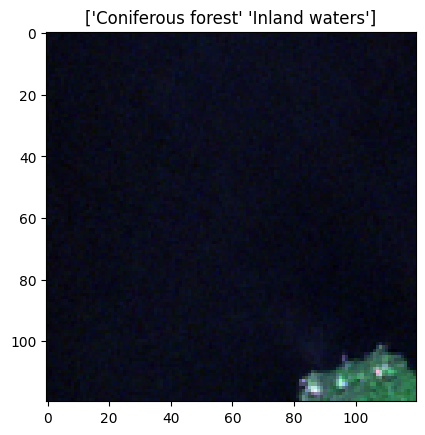

In [22]:
import matplotlib.pyplot as plt
def normalize(tensor):
    """Normalize each band to [0, 1] range."""
    tensor = tensor.clone()
    for i in range(tensor.shape[0]):
        band = tensor[i]
        min_val = band.min()
        max_val = band.max()
        if max_val > min_val:  # avoid division by zero
            tensor[i] = (band - min_val) / (max_val - min_val)
    return tensor


plt.imshow(normalize(img_interp[[3,2,1],:,:]).permute(1,2,0))
plt.title(labels_data)

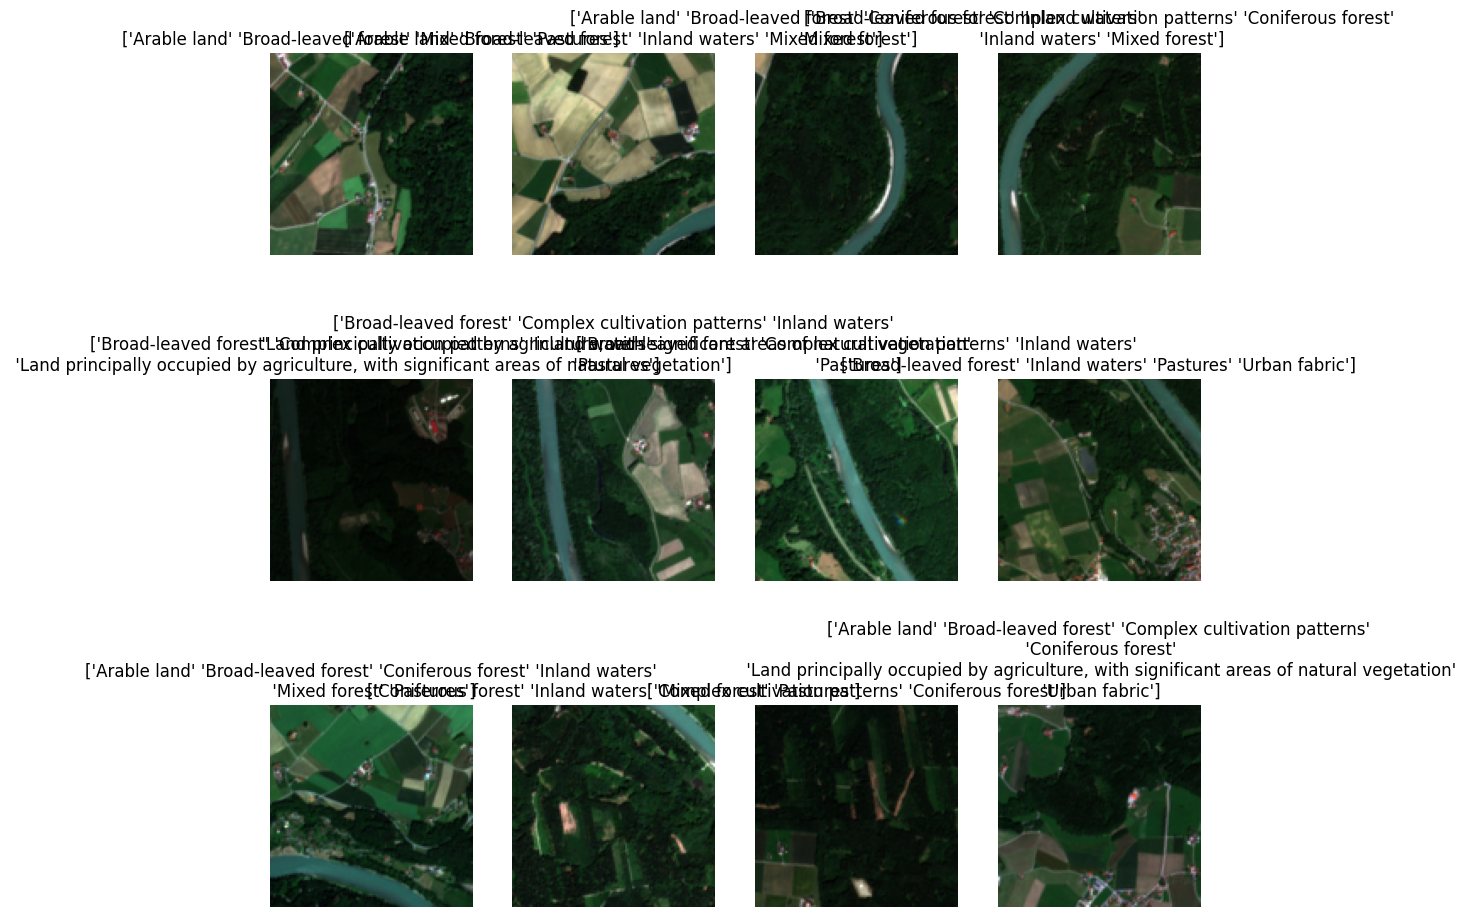

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 4, figsize=(12, 12))

for row in df_parquet[:12].iterrows():

    ## get image
    image_data, labels = tryier.__getitem__(row[1]['patch_id'])

    ## interpolate 
    img_interp = stack_and_interpolate(
    bands= image_data,
    order = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
    img_size = 120,
    upsample_mode= 'bilinear'
)   
    ##normalize and plot it 
    img_norm = normalize(img_interp[[3,2,1],:,:]).permute(1,2,0)

    #fix_labels = labels.split
    # Plot the patch
    if row[0]<4:
        axes[0, row[0]].imshow(img_norm)
        axes[0, row[0]].set_title(labels)
        axes[0, row[0]].axis('off')  # Remove axis ticks and labels
    elif (row[0]>=4) & (row[0]<8):
        axes[1, (row[0]%4)].imshow(img_norm)
        axes[1, (row[0]%4)].set_title(labels)
        axes[1, (row[0]%4)].axis('off')  # Remove axis ticks and labels
    else:
        axes[2, (row[0]%4)].imshow(img_norm)
        axes[2, (row[0]%4)].set_title(labels)
        axes[2, (row[0]%4)].axis('off')  # Remove axis ticks and labels


 
    

In [33]:
labels

array(['Arable land', 'Broad-leaved forest',
       'Complex cultivation patterns', 'Coniferous forest',
       'Land principally occupied by agriculture, with significant areas of natural vegetation',
       'Urban fabric'], dtype=object)

## DATASET

In [48]:
from torchvision import transforms

In [54]:
mean_dict

{'B01': 361.0767822265625,
 'B02': 438.3720703125,
 'B03': 614.0556640625,
 'B04': 588.4096069335938,
 'B05': 942.8433227539062,
 'B06': 1769.931640625,
 'B07': 2049.551513671875,
 'B08': 2193.2919921875,
 'B09': 2241.455322265625,
 'B11': 1568.226806640625,
 'B12': 997.7324829101562,
 'B8A': 2235.556640625,
 'VH': -19.352558135986328,
 'VV': -12.643863677978516}

In [57]:
def get_right_dict(s2_dict_mean,s2_dict_std, upsampling_method='nearest'):       
        name_upsample = f"120_{upsampling_method}"
        mean_dict = s2_dict_mean[name_upsample]
        std_dict = s2_dict_std[name_upsample]
        return mean_dict,std_dict

In [ ]:
mean_dict, std_dict = get_right_dict(s2_dict_mean=means_s2,s2_dict_std=stds_s2,upsampling_method='nearest')

In [59]:
def get_list_means_std(mean_dict,std_dict,strip_bands):
        """Extract mean and std values for each band from dictionaries."""
        list_mean, list_std = [],[]
        for band in strip_bands:
            list_mean.append(mean_dict[band])
            list_std.append(std_dict[band])
            
        return list_mean, list_std

In [60]:
list_mean, list_std = get_list_means_std(mean_dict=mean_dict,std_dict=std_dict,
                                         strip_bands=["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"])

In [90]:
datasetmod = Dataset_BigEarthNet(
    lmdb_reader= tryier,
    strip_bands = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
    img_size= 120,
    upsample_mode='nearest',
    normalize =True,
    split_train_test= 'train',
    dict_one_hot=label_to_idx,
    transform= transforms.Compose([
        transforms.Normalize(mean=list_mean, std=list_std),
        transforms.Resize([224,224])
    ])
)

2025-08-11 09:06:58.471 | INFO     | __main__:__init__:70 - Using the partition: train with len272544


In [24]:
datasetmod.strip_bands

['B01',
 'B02',
 'B03',
 'B04',
 'B05',
 'B06',
 'B07',
 'B08',
 'B8A',
 'B09',
 'B11',
 'B12']

In [25]:
datasetmod.__patch_id__(12)

'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_40_79'

In [62]:
datasetmod.__getitem__(0)

(tensor([[[0.6241, 0.6241, 0.6241,  ..., 1.2067, 1.2067, 1.2067],
          [0.6241, 0.6241, 0.6241,  ..., 1.2067, 1.2067, 1.2067],
          [0.6241, 0.6241, 0.6241,  ..., 1.2067, 1.2067, 1.2067],
          ...,
          [0.1199, 0.1199, 0.1199,  ..., 0.4850, 0.4850, 0.4850],
          [0.1199, 0.1199, 0.1199,  ..., 0.4850, 0.4850, 0.4850],
          [0.1199, 0.1199, 0.1199,  ..., 0.4850, 0.4850, 0.4850]],
 
         [[0.1361, 0.2216, 0.3725,  ..., 2.3271, 2.4754, 2.5594],
          [0.2171, 0.3049, 0.4599,  ..., 2.2904, 2.4327, 2.5134],
          [0.3601, 0.4519, 0.6139,  ..., 2.2255, 2.3574, 2.4322],
          ...,
          [0.0945, 0.0709, 0.0291,  ..., 0.8174, 0.8544, 0.8753],
          [0.1810, 0.1268, 0.0311,  ..., 0.6188, 0.7465, 0.8188],
          [0.2300, 0.1585, 0.0323,  ..., 0.5062, 0.6853, 0.7868]],
 
         [[0.4673, 0.4482, 0.4145,  ..., 1.9597, 2.1604, 2.2741],
          [0.5619, 0.5413, 0.5049,  ..., 1.9348, 2.1263, 2.2348],
          [0.7289, 0.7055, 0.6643,  ...,

In [63]:
img_test, label_tst, _= datasetmod.__getitem__(0)

In [64]:
img_test.shape

torch.Size([12, 224, 224])

In [65]:
datasetmod.df_split_("split")

,patch_id,split
0,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,test
1,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,test
2,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,test
3,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,test
4,S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_2...,test
...,...,...
69445,S2B_MSIL2A_20180522T093029_N9999_R136_T35VPJ_6...,train
69446,S2B_MSIL2A_20180522T093029_N9999_R136_T35VPJ_6...,validation
69447,S2B_MSIL2A_20180522T093029_N9999_R136_T35VPJ_6...,validation
69448,S2B_MSIL2A_20180522T093029_N9999_R136_T35VPJ_6...,test


## DATAMODULE

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

dataloader_train = DataLoader(
            dataset = datasetmod,
            batch_size= 8,
            shuffle = False,
            num_workers = 4,
            pin_memory = False
        )

In [29]:
datasetmod.strip_bands

['B01',
 'B02',
 'B03',
 'B04',
 'B05',
 'B06',
 'B07',
 'B08',
 'B8A',
 'B09',
 'B11',
 'B12']

In [30]:
for band in datasetmod.strip_bands:
    print(means_s2['120_bicubic'][band])

360.637451171875
438.3720703125
614.0556640625
588.4096069335938
942.7472534179688
1769.8485107421875
2049.475830078125
2193.2919921875
2235.48681640625
2241.091064453125
1568.2117919921875
997.715087890625


In [31]:
print('train',len(df_parquet.loc[df_parquet['split']=='train']))
print('val',len(df_parquet.loc[df_parquet['split']=='validation']))
print('test',len(df_parquet.loc[df_parquet['split']=='test']))

train 237871
val 122342
test 119825


In [42]:
means_s2 = {
    "120_nearest": {
        "B01": 361.0767822265625,
        "B02": 438.3720703125,
        "B03": 614.0556640625,
        "B04": 588.4096069335938,
        "B05": 942.8433227539062,
        "B06": 1769.931640625,
        "B07": 2049.551513671875,
        "B08": 2193.2919921875,
        "B09": 2241.455322265625,
        "B11": 1568.226806640625,
        "B12": 997.7324829101562,
        "B8A": 2235.556640625,
        "VH": -19.352558135986328,
        "VV": -12.643863677978516,
    },
    "120_bilinear": {
        "B01": 360.64678955078125,
        "B02": 438.3720703125,
        "B03": 614.0556640625,
        "B04": 588.4096069335938,
        "B05": 942.7476806640625,
        "B06": 1769.8486328125,
        "B07": 2049.475830078125,
        "B08": 2193.2919921875,
        "B09": 2241.10595703125,
        "B11": 1568.2115478515625,
        "B12": 997.715087890625,
        "B8A": 2235.48681640625,
        "VH": -19.352558135986328,
        "VV": -12.643863677978516,
    },
    "120_bicubic": {
        "B01": 360.637451171875,
        "B02": 438.3720703125,
        "B03": 614.0556640625,
        "B04": 588.4096069335938,
        "B05": 942.7472534179688,
        "B06": 1769.8485107421875,
        "B07": 2049.475830078125,
        "B08": 2193.2919921875,
        "B09": 2241.091064453125,
        "B11": 1568.2117919921875,
        "B12": 997.715087890625,
        "B8A": 2235.48681640625,
        "VH": -19.352558135986328,
        "VV": -12.643863677978516,
    }
}

stds_s2 = {
        "120_nearest": {
        "B01": 575.0687255859375,
        "B02": 607.02685546875,
        "B03": 603.2968139648438,
        "B04": 684.56884765625,
        "B05": 738.4326782226562,
        "B06": 1100.4560546875,
        "B07": 1275.805419921875,
        "B08": 1369.3717041015625,
        "B09": 1316.393310546875,
        "B11": 1070.1612548828125,
        "B12": 813.5276489257812,
        "B8A": 1356.5440673828125,
        "VH": 5.590505599975586,
        "VV": 5.133493900299072,
    },
    "120_bilinear": {
        "B01": 563.1734008789062,
        "B02": 607.02685546875,
        "B03": 603.2968139648438,
        "B04": 684.56884765625,
        "B05": 727.5784301757812,
        "B06": 1087.4288330078125,
        "B07": 1261.4302978515625,
        "B08": 1369.3717041015625,
        "B09": 1294.35546875,
        "B11": 1063.9197998046875,
        "B12": 806.8846435546875,
        "B8A": 1342.490478515625,
        "VH": 5.590505599975586,
        "VV": 5.133493900299072,
    },
    "120_bicubic": {
        "B01": 572.3436889648438,
        "B02": 607.02685546875,
        "B03": 603.2968139648438,
        "B04": 684.56884765625,
        "B05": 738.3037719726562,
        "B06": 1100.46142578125,
        "B07": 1275.843505859375,
        "B08": 1369.3717041015625,
        "B09": 1313.6488037109375,
        "B11": 1070.8011474609375,
        "B12": 814.0936279296875,
        "B8A": 1356.754150390625,
        "VH": 5.590505599975586,
        "VV": 5.133493900299072,
    }
}

In [91]:
img_test, label_test,_ = datasetmod.__getitem__(0)
img_test.shape

torch.Size([12, 224, 224])

Text(0.5, 1.0, '[[0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0]]')

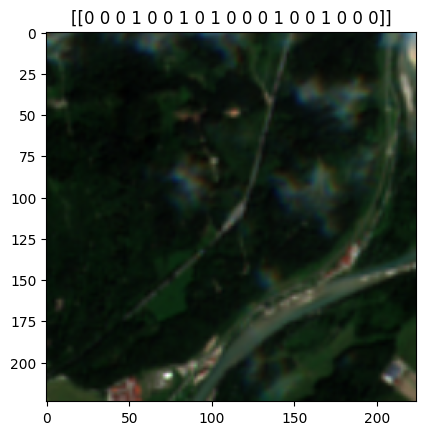

In [80]:
plt.imshow(normalize(img_test[[3,2,1],:,:]).permute(1,2,0))
plt.title(label_test)

In [81]:
datasetmod.__len__()

272544

In [82]:
import random

In [84]:
random.randint(0,datasetmod.__len__())

108226

In [98]:
mlb = MultiLabelBinarizer().fit([label_to_idx.keys()])

In [109]:
label_to_idx.keys()

dict_keys(['Arable land', 'Broad-leaved forest', 'Mixed forest', 'Pastures', 'Inland waters', 'Coniferous forest', 'Complex cultivation patterns', 'Land principally occupied by agriculture, with significant areas of natural vegetation', 'Urban fabric', 'Industrial or commercial units', 'Inland wetlands', 'Transitional woodland, shrub', 'Natural grassland and sparsely vegetated areas', 'Moors, heathland and sclerophyllous vegetation', 'Marine waters', 'Coastal wetlands', 'Permanent crops', 'Beaches, dunes, sands', 'Agro-forestry areas'])

In [111]:
mlb.transform([['Arable land', 'Broad-leaved forest']])

array([[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [116]:
mlb.inverse_transform(np.array([[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]))

[('Arable land', 'Broad-leaved forest')]

In [105]:
label_test.tolist()[0]

[0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0]

In [108]:
mlb.inverse_transform([[0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0]])

AttributeError: 'list' object has no attribute 'shape'

In [107]:
mlb.inverse_transform([np.ndarray(label_test.tolist())[0]
                       ])

TypeError: 'list' object cannot be interpreted as an integer

In [95]:
type(label_test.tolist())

list

In [127]:
def plot_images_dataset(dataset, label_to_idx, num_images=10):
    # Get random starting index, ensuring we don't go out of bounds
    max_start = len(dataset) - num_images
    rand_start = random.randint(0, max_start)
    
    # Create MultiLabelBinarizer (though you may not need this depending on your label format)
    mlb = MultiLabelBinarizer().fit([label_to_idx.keys()])
    
    # Calculate grid dimensions
    cols = min(5, num_images)  # Max 5 columns
    rows = (num_images + cols - 1) // cols  # Ceiling division
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    
    # Handle case where we have only one subplot
    if num_images == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_images):
        row = i // cols
        col = i % cols
        
        try:
            img, labels, _ = dataset[rand_start + i]
            
            # Handle the image normalization and channel reordering
            if isinstance(img, torch.Tensor):
                # Assuming img is in format (C, H, W) and you want RGB channels [2,1,0] for BGR->RGB
                if img.shape[0] >= 4:  # If you have at least 4 channels
                    display_img = img[[2, 1, 0], :, :].permute(1, 2, 0)  # Take channels 2,1,0 and convert to (H,W,C)
                else:
                    display_img = img.permute(1, 2, 0) if img.dim() == 3 else img
                
                # Normalize if needed (assuming you have a normalize function)
                # If you don't have a normalize function, you can remove this or define it
                try:
                    display_img = normalize(display_img)
                except NameError:
                    # Simple normalization if normalize function doesn't exist
                    display_img = (display_img - display_img.min()) / (display_img.max() - display_img.min())
            else:
                display_img = img
            
            # Plot the image
            if rows == 1:
                ax = axes[col]
            else:
                ax = axes[row, col]
                
            ax.imshow(display_img)
            ax.axis('off')
            
            # Handle labels - this depends on your label format
            if isinstance(labels, torch.Tensor):
                if labels.dim() > 0:
                    # If labels is a multi-hot vector, convert to list of label names
                    label_names = mlb.inverse_transform(np.array(labels.tolist()))[0]
                   # print(label_names[0])
                    title = ', '.join(label_names) if label_names else 'No labels'
                else:
                    # Single label
                    label_idx = labels.item()
                    title = list(label_to_idx.keys())[list(label_to_idx.values()).index(label_idx)]
            else:
                title = str(labels)
            
            ax.set_title(title, fontsize=10)
            
        except IndexError:
            # Hide unused subplots
            if rows == 1:
                axes[col].axis('off')
            else:
                axes[row, col].axis('off')
    
    # Hide any remaining unused subplots
    total_subplots = rows * cols
    for i in range(num_images, total_subplots):
        row = i // cols
        col = i % cols
        if rows == 1:
            axes[col].axis('off')
        else:
            axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

# Alternative normalize function if you don't have one
def normalize(tensor):
    """Simple normalization to [0, 1] range"""
    return (tensor - tensor.min()) / (tensor.max() - tensor.min())

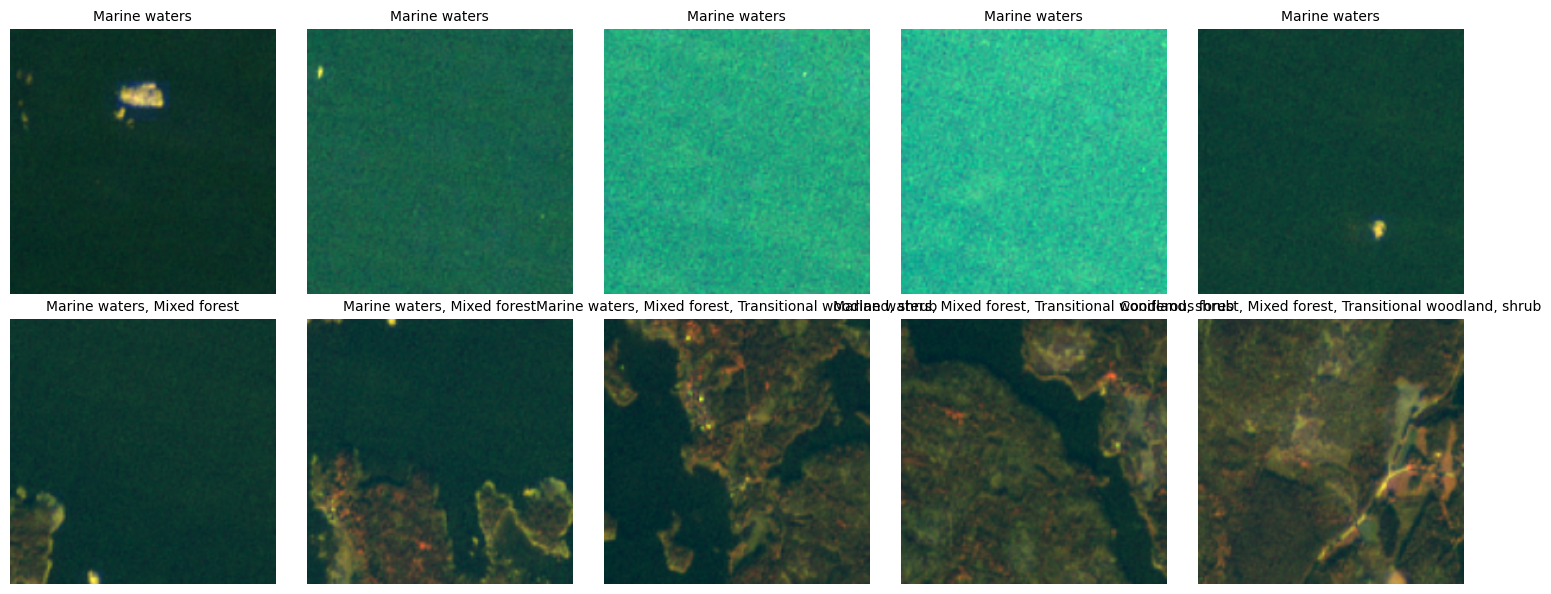

In [128]:
plot_images_dataset(datasetmod,label_to_idx,10)

In [139]:
for x_train, y_train,_ in dataloader_train.dataset:
    print(x_train.shape, y_train.shape)

torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224, 224]) (1, 19)
torch.Size([12, 224,

KeyboardInterrupt: 

In [144]:
len(dataloader_train)

17034

In [130]:

try:
    for i, batch in enumerate(dataloader_train):
        if len(batch) == 3:  # img_tensor, labels_onehot, patch_id
            img_tensor, labels_onehot, patch_id = batch
        else:  # img_tensor, labels_onehot
            img_tensor, labels_onehot = batch
            patch_id = None
        
        print(f"Batch {i}:")
        print(f"  Image tensor shape: {img_tensor.shape}")
        print(f"  Labels shape: {labels_onehot.shape}")
        if patch_id is not None:
            print(f"  Patch IDs: {patch_id}")
        
        # Only test first few batches
        if i >= 2:
            break
            
except Exception as e:
    print(f"DataLoader failed: {e}")

Batch 0:
  Image tensor shape: torch.Size([16, 12, 224, 224])
  Labels shape: torch.Size([16, 1, 19])
  Patch IDs: ('S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_88', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_89', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_37_90', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_38_88', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_38_89', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_38_90', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_39_86', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_39_87', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_39_88', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_39_89', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_39_90', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_40_78', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_40_79', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_40_84', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_40_85', 'S2A_MSIL2A_20170613T101031_N9999_R022_T33UUP_40_86')
Batch 1:
  Image ten

In [131]:
# Check data types and value ranges
batch = next(iter(dataloader_train))
img_tensor, labels_onehot = batch[0], batch[1]

print(f"Image tensor dtype: {img_tensor.dtype}")
print(f"Labels dtype: {labels_onehot.dtype}")
print(f"Image value range: [{img_tensor.min():.4f}, {img_tensor.max():.4f}]")
print(f"Image mean: {img_tensor.mean():.4f}")
print(f"Image std: {img_tensor.std():.4f}")
print(f"Labels sum per sample: {labels_onehot.sum(dim=1)}")  # Should be >0 for multi-label

Image tensor dtype: torch.float32
Labels dtype: torch.int64
Image value range: [-1.5696, 11.5116]
Image mean: 0.4942
Image std: 0.7497
Labels sum per sample: tensor([[0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1],
        [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1],
        [0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
        [0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1],
        [0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1],
        [0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
        [0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 1, 0,

In [132]:
# Test if your transforms are applied correctly
def test_single_sample():
    # Get one sample directly from dataset (bypasses DataLoader batching)
    sample = datasetmod[0]
    
    if len(sample) == 3:
        img, labels, patch_id = sample
    else:
        img, labels = sample
    
    print(f"Single sample image shape: {img.shape}")
    print(f"Expected shape after transforms: [12, 224, 224]")  # 12 bands, 224x224 after resize
    
    # Verify the resize transform worked
    assert img.shape[-2:] == (224, 224), "Resize transform not applied correctly"
    
    return img, labels

test_single_sample()

Single sample image shape: torch.Size([12, 224, 224])
Expected shape after transforms: [12, 224, 224]


(tensor([[[0.6241, 0.6241, 0.6241,  ..., 1.2067, 1.2067, 1.2067],
          [0.6241, 0.6241, 0.6241,  ..., 1.2067, 1.2067, 1.2067],
          [0.6241, 0.6241, 0.6241,  ..., 1.2067, 1.2067, 1.2067],
          ...,
          [0.1199, 0.1199, 0.1199,  ..., 0.4850, 0.4850, 0.4850],
          [0.1199, 0.1199, 0.1199,  ..., 0.4850, 0.4850, 0.4850],
          [0.1199, 0.1199, 0.1199,  ..., 0.4850, 0.4850, 0.4850]],
 
         [[0.1361, 0.2216, 0.3725,  ..., 2.3271, 2.4754, 2.5594],
          [0.2171, 0.3049, 0.4599,  ..., 2.2904, 2.4327, 2.5134],
          [0.3601, 0.4519, 0.6139,  ..., 2.2255, 2.3574, 2.4322],
          ...,
          [0.0945, 0.0709, 0.0291,  ..., 0.8174, 0.8544, 0.8753],
          [0.1810, 0.1268, 0.0311,  ..., 0.6188, 0.7465, 0.8188],
          [0.2300, 0.1585, 0.0323,  ..., 0.5062, 0.6853, 0.7868]],
 
         [[0.4673, 0.4482, 0.4145,  ..., 1.9597, 2.1604, 2.2741],
          [0.5619, 0.5413, 0.5049,  ..., 1.9348, 2.1263, 2.2348],
          [0.7289, 0.7055, 0.6643,  ...,

In [133]:
import time
import torch

# Test memory usage and loading speed
def performance_test(dataloader, num_batches=10):
    start_time = time.time()
    
    for i, batch in enumerate(dataloader):
        if i >= num_batches:
            break
        
        # Simulate some processing
        img_tensor = batch[0]
        _ = img_tensor.mean()  # Simple operation
        
        if i == 0:
            print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB" if torch.cuda.is_available() else "CPU mode")
    
    end_time = time.time()
    print(f"Loaded {num_batches} batches in {end_time - start_time:.2f} seconds")
    print(f"Average time per batch: {(end_time - start_time) / num_batches:.3f} seconds")

performance_test(dataloader_train)

ERROR: Unexpected segmentation fault encountered in worker.
 Exception ignored in: <function _TemporaryFileCloser.__del__ at 0x7f5deec698a0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/tempfile.py", line 611, in __del__
    self.cleanup()
  File "/usr/lib/python3.12/tempfile.py", line 591, in cleanup
    self.file.close()
  File "/root/bigearthnet/BigEarthNet-Models/.venv/lib/python3.12/site-packages/torch/utils/data/_utils/signal_handling.py", line 73, in handler
    _error_if_any_worker_fails()
RuntimeError: DataLoader worker (pid 934728) is killed by signal: Segmentation fault. 


GPU memory allocated: 0.00 GB


ConnectionResetError: [Errno 104] Connection reset by peer

In [134]:
def safe_performance_test(dataloader, num_batches=10):
    """Performance test with error handling"""
    import time
    
    start_time = time.time()
    successful_batches = 0
    
    try:
        for i, batch in enumerate(dataloader):
            if i >= num_batches:
                break
            
            try:
                # Simulate some processing
                img_tensor = batch[0]
                _ = img_tensor.mean()
                successful_batches += 1
                
                print(f"Batch {i} loaded successfully. Shape: {img_tensor.shape}")
                
            except Exception as batch_error:
                print(f"Error in batch {i}: {batch_error}")
                continue
                
    except Exception as dataloader_error:
        print(f"DataLoader error: {dataloader_error}")
    
    end_time = time.time()
    print(f"Successfully loaded {successful_batches}/{num_batches} batches in {end_time - start_time:.2f} seconds")

# Test with different configurations
print("Testing with 0 workers:")
safe_performance_test(dataloader_train_debug, 3)

print("\nTesting with 1 worker:")
dataloader_1_worker = DataLoader(datasetmod, batch_size=4, num_workers=1, pin_memory=False)
safe_performance_test(dataloader_1_worker, 3)

Testing with 0 workers:


NameError: name 'dataloader_train_debug' is not defined

In [186]:
df_parquet[['labels']].get_dummies(df_parquet['labels'])

AttributeError: 'DataFrame' object has no attribute 'get_dummies'

In [187]:
pd.get_dummies(df_parquet['labels'])

TypeError: unhashable type: 'numpy.ndarray'

## Calculate unbalanced

In [ ]:
df_parquet['labels'].i

array(['Arable land', 'Broad-leaved forest', 'Mixed forest', 'Pastures'],
      dtype=object)

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

df_sum = pd.DataFrame()
labels_df.sum(0)
#df_sum['perc'] =
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100

,Agro-forestry areas,Arable land,"Beaches, dunes, sands",Broad-leaved forest,Coastal wetlands,Complex cultivation patterns,Coniferous forest,Industrial or commercial units,Inland waters,Inland wetlands,"Land principally occupied by agriculture, with significant areas of natural vegetation",Marine waters,Mixed forest,"Moors, heathland and sclerophyllous vegetation",Natural grassland and sparsely vegetated areas,Pastures,Permanent crops,"Transitional woodland, shrub",Urban fabric
0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
2,0,1,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0
3,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0,0,0,0,0
4,0,0,0,1,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0


In [238]:
df_sum = pd.DataFrame()
labels_df.sum(0)
#df_sum['perc'] =
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100

In [239]:
df_sum

,sum,percent
0,33181,2.343528
1,188025,13.279943
2,1316,0.092947
3,135928,9.600405
4,1397,0.098668
5,99598,7.034467
6,154941,10.943266
7,11142,0.786944
8,63212,4.464575
9,20919,1.477480


### Train - Unabalanced

In [240]:

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'].loc[df_parquet['split']=='train'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

df_sum = pd.DataFrame()
labels_df.sum(0)
#df_sum['perc'] =
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100

df_sum

,sum,percent
0,15082,2.190232
1,88236,12.813769
2,738,0.107174
3,64164,9.317996
4,670,0.097298
5,51034,7.411237
6,76344,11.086795
7,6398,0.929128
8,30466,4.424320
9,11344,1.647393


In [242]:
labels_matrix = mlb.fit_transform(df_parquet['labels'].loc[df_parquet['split']=='validation'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

df_sum = pd.DataFrame()
labels_df.sum(0)
#df_sum['perc'] =
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100

df_sum

,sum,percent
0,8157,2.214308
1,49737,13.501657
2,426,0.115642
3,35387,9.606191
4,610,0.165591
5,26486,7.189917
6,39554,10.737370
7,2726,0.740003
8,15900,4.316230
9,5056,1.372507


In [232]:
np.clip((labels_df.sum(0)/labels_df.sum(0).values.sum()),0.01,0.09)

Agro-forestry areas                                                                       0.021902
Arable land                                                                               0.090000
Beaches, dunes, sands                                                                     0.010000
Broad-leaved forest                                                                       0.090000
Coastal wetlands                                                                          0.010000
Complex cultivation patterns                                                              0.074112
Coniferous forest                                                                         0.090000
Industrial or commercial units                                                            0.010000
Inland waters                                                                             0.044243
Inland wetlands                                                                           0.016474
Land princ

In [243]:
 ff = np.array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0.])

In [244]:
ff.argmax()

12

In [195]:
df_parquet.iloc[0]['labels']

array(['Arable land', 'Broad-leaved forest', 'Mixed forest', 'Pastures'],
      dtype=object)

In [202]:
new_label_to_idx = {}
for num, ind in enumerate(labels_df.iloc[0].index):
    new_label_to_idx[ind] = num

In [203]:
new_label_to_idx

{'Agro-forestry areas': 0,
 'Arable land': 1,
 'Beaches, dunes, sands': 2,
 'Broad-leaved forest': 3,
 'Coastal wetlands': 4,
 'Complex cultivation patterns': 5,
 'Coniferous forest': 6,
 'Industrial or commercial units': 7,
 'Inland waters': 8,
 'Inland wetlands': 9,
 'Land principally occupied by agriculture, with significant areas of natural vegetation': 10,
 'Marine waters': 11,
 'Mixed forest': 12,
 'Moors, heathland and sclerophyllous vegetation': 13,
 'Natural grassland and sparsely vegetated areas': 14,
 'Pastures': 15,
 'Permanent crops': 16,
 'Transitional woodland, shrub': 17,
 'Urban fabric': 18}